## MNP로 MNIST Classification
핵심 개념
Dataset 정제과정
1. Numpy 배열을 Pytorch tensor로 변환
2. Dataset으로 묶음
3. DataLoader로 배치 단위로 분할

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [3]:
# MNIST 데이터셋 불러오기
mnist = fetch_openml('mnist_784', version = 1, cache = True, as_frame= False)

In [5]:
mnist.data[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [9]:
mnist.target[0] # 문자열임

'5'

In [11]:
mnist.target = mnist.target.astype(np.int8) # 정수형으로 변환

In [17]:
X = mnist.data / 255 # 0 ~ 255 값을 [0,1]으로 정규화
y = mnist.target # label 값. 이게 나중에 실제값이 되어 비교하게 됨

In [14]:
X[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [19]:
y[0]

np.int8(5)

이 이미지 데이터의 레이블은 5이다.


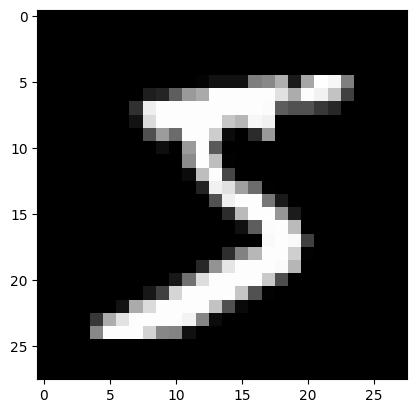

In [21]:
plt.imshow(X[0].reshape(28,28),cmap = 'gray')
print('이 이미지 데이터의 레이블은 {}이다.'.format(y[0]))

In [25]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/7, random_state= 0)
# test_size = 1/7인거는 Train data가 6/7의 비율, Test data가 1/7의 비율임
# random_state = 0이 의미하는건 데이터를 분할할때 랜덤으로 섞는지 유무임 0이면 항상 같은 데이터로 분할

In [28]:
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Dataset 객체 생성
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)

# Dataloader 객체 생성
loader_train = DataLoader(ds_train, batch_size = 64, shuffle=True)
loader_test = DataLoader(ds_test, batch_size = 64, shuffle=False)


# Dataset 정제과정
# 1. Numpy 배열을 Pytorch tensor로 변환
# 2. Dataset으로 묶음
# 3. DataLoader로 배치 단위로 분할

In [29]:
# MLP
from torch import nn
from torch import optim

In [34]:
model = nn.Sequential()
model.add_module('fc1', nn.Linear(28*28*1, 100)) # 28*28개의 input 뉴런, 100개의 은닉뉴런
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(100, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('fc3', nn.Linear(100,10))

print(model)

Sequential(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [35]:
# loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [39]:
epochs = 3
for epoch in range(epochs):
    for data, targets in loader_train:
        optimizer.zero_grad()
        y_pred = model(data)
        loss = loss_fn(y_pred, targets)
        loss.backward()
        optimizer.step()
    print('Epoch {:4d}/{} Cost : {:.6f}'.format(epoch + 1, 3, loss.item()))

Epoch    1/3 Cost : 0.012243
Epoch    2/3 Cost : 0.118537
Epoch    3/3 Cost : 0.000699


In [40]:
model.eval()
correct = 0

In [41]:
with torch.no_grad():
    for data, targets in loader_test:
        outputs = model(data) # 데이터 입력하고 출력 계산
        # 추론 계산
        _, predicted = torch.max(outputs.data, 1)
        correct += predicted.eq(targets.data.view_as(predicted)).sum()
# 정확도 출력
data_num = len(loader_test.dataset)
print('\n 테스트 데이터에서 예측 정확도 : {}/{} ({:.0f}%)\n'.format(correct, data_num, 100. * correct/ data_num))


 테스트 데이터에서 예측 정확도 : 9645/10000 (96%)



예측 결과 : 7
이 이미지 데이터의 정답 레이블은 7입니다


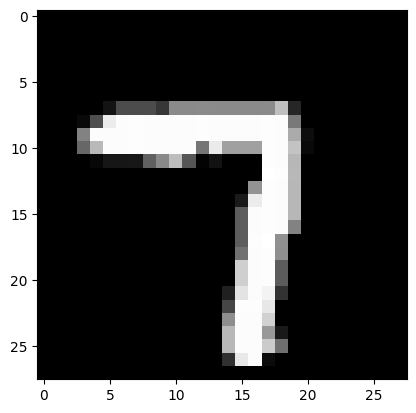

In [66]:
index = 6

model.eval()  # 신경망을 추론 모드로 전환
data = X_test[index]
output = model(data)  # 데이터를 입력하고 출력을 계산
_, predicted = torch.max(output.data, 0)  # 확률이 가장 높은 레이블이 무엇인지 계산

print("예측 결과 : {}".format(predicted))

X_test_show = (X_test[index]).numpy()
plt.imshow(X_test_show.reshape(28, 28), cmap='gray')
print("이 이미지 데이터의 정답 레이블은 {:.0f}입니다".format(y_test[index]))